# Lab Assignment 8: NLP Topic Modeling on Health-Related Headlines (AI in Healthcare)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/achalzz/ai-healthcare-cset343/blob/main/Lab_Assignment_8_AI_in_Healthcare.ipynb)

**Course:** B.Tech Specialization Elective (4th Year, Sem VII)  
**Course Code:** CSET343 - AI in Healthcare  
**Assignment:** Lab Assignment 8 - NLP Text Analysis & Topic Modeling on Health-Related Headlines  

---

### Objectives & Agenda:
1. **Task 1: Data Preprocessing and Cleaning**
   - Load the Health-Related Headlines dataset from GitHub (CSV format)
   - Perform Tokenization, Stop-word removal, Lemmatization, Lowercasing, and Punctuation removal
   - Display a few cleaned text samples
2. **Task 2: Exploratory Text Analysis & Word Visualization**
   - Generate Word frequency distribution
   - Plot Top 20 frequent words using Matplotlib / Seaborn
   - Generate Word Cloud showing the most common health-related terms
3. **Task 3: Topic Modelling using LDA (Latent Dirichlet Allocation)**
   - Use the cleaned text corpus to identify dominant health-related topics
   - Display top 5 words per topic
   - Visualize the results using pyLDAvis


In [1]:
# [HINGLISH CODE EXPLANATION]:
# NLP aur Topic Modeling ke zaroori libraries import aur download kar rahe hain.
# !pip install wordcloud pyldavis -q

import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# NLP tools
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Topic Modeling (LDA) & WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'wordcloud', '-q'])
    from wordcloud import WordCloud

try:
    import pyLDAvis
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pyLDAvis', '-q'])
    import pyLDAvis

sns.set_theme(style="whitegrid")
print("[INFO] All required libraries imported successfully!")


[INFO] All required libraries imported successfully!


---
## Task 1: Data Preprocessing and Cleaning
- Load the Health-Related Headlines dataset from GitHub
- Perform: Lowercasing, Punctuation removal, Tokenization, Stop-word removal, and Lemmatization
- Display cleaned text samples


In [2]:
# [HINGLISH CODE EXPLANATION]:
# Health Headlines dataset GitHub repository se load kar rahe hain.
url = "https://raw.githubusercontent.com/WuraolaOyewusi/Health-Related-Headlines-Datasets-for-Natural-Language-Processing/master/Health_Related_Headlines_Dataset.csv"
df = pd.read_csv(url)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
display(df.head())


,Date,Source,Headlines,Teaser,Category
0,"January, 1970",Medscape Special Reports,Special Report: Adult Vaccines -- New ACIP Recommendations,New recommendations for already approved vaccines and a newly approved vaccine for meningococcal B infections -- what you need to know.,Immunization
1,"January, 1970",Medscape Medical News,Combined Internet and Telephone Intervention May Facilitate Smoking Cessation,"In a randomized trial, combined Internet and telephone treatment of smoking cessation outperformed static and dynamic Internet interventions.",Substance Abuse and Addiction
2,"April, 1997",Medscape Psychiatry & Mental Health eJournal [TM],Link Between Parental Alcoholism and Childhood Mood Disorders,It is proposed that depressed children identify families with a specific form of bipolar disorder similar to alcoholism.,Substance Abuse and Addiction
3,"November, 1997",Medscape Psychiatry & Mental Health eJournal [TM],Methadone Dose in the Treatment of Opiate Dependence,The epidemic of heroin abuse within the US has produced an influx of addicts requiring effective opioid substitution.,Substance Abuse and Addiction
4,"March, 2000",Medscape Medical News,Magnet Treatment Had No Beneficial Effect on Patients With Chronic Low...,"A small study using one variety of magnet for treatment of low back pain had no effect on patients' pain; however, the researchers say that additional studies are needed to verify the results of this pilot study, according to an article in the March 8 issue of The Journal of the American Medical Association.",Pain Management


Dataset Shape: 39405 rows, 5 columns
               Date                                             Source                                                                      Headlines                                                                                                                                                                                                                                                                                                                  Teaser                       Category
0    January, 1970                            Medscape Special Reports                     Special Report: Adult Vaccines -- New ACIP Recommendations                                                                                                                                                                                 New recommendations for already approved vaccines and a newly approved vaccine for meningococcal B infections -- what you need to know.         

In [3]:
# [HINGLISH CODE EXPLANATION]:
# NLP preprocessing pipeline: lowercasing, punctuation removal, tokenization,
# stop-words removal aur lemmatization apply kar rahe hain.
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercase aur punctuation/numbers remove karna
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    # 2. Tokenize karna
    try:
        tokens = word_tokenize(text)
    except Exception:
        tokens = text.split()
    # 3. Stop-words remove aur lemmatize karna
    cleaned = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(cleaned)

# Headlines par preprocessing apply karna
df['Cleaned_Headlines'] = df['Headlines'].apply(preprocess_text)

# Cleaned text samples display karna (Original vs Cleaned)
print("=== SAMPLE TEXT PREPROCESSING (BEFORE vs AFTER) ===\n")
for idx, (orig, clean) in enumerate(zip(df['Headlines'].head(5), df['Cleaned_Headlines'].head(5)), 1):
    print(f"Sample {idx}:")
    print(f"  ORIGINAL: {orig}")
    print(f"  CLEANED : {clean}\n")


=== SAMPLE TEXT PREPROCESSING (BEFORE vs AFTER) ===

Sample 1:
  ORIGINAL: Special Report: Adult Vaccines -- New ACIP Recommendations
  CLEANED : special report adult vaccine new acip recommendation

Sample 2:
  ORIGINAL: Combined Internet and Telephone Intervention May Facilitate Smoking Cessation
  CLEANED : combined internet telephone intervention may facilitate smoking cessation

Sample 3:
  ORIGINAL: Link Between Parental Alcoholism and Childhood Mood Disorders
  CLEANED : link parental alcoholism childhood mood disorder

Sample 4:
  ORIGINAL: Methadone Dose in the Treatment of Opiate Dependence
  CLEANED : methadone dose treatment opiate dependence

Sample 5:
  ORIGINAL: Magnet Treatment Had No Beneficial Effect on Patients With Chronic Low...
  CLEANED : magnet treatment beneficial effect patient chronic low



---
## Task 2: Exploratory Text Analysis & Word Visualization
- Generate word frequency distribution
- Plot Top 20 most frequent health-related words using Seaborn
- Generate Word Cloud showing the most common health terms


,Word,Frequency
0,patient,2781
1,risk,2471
2,cancer,2406
3,pain,2303
4,drug,2197
5,new,1729
6,vaccine,1586
7,may,1566
8,use,1544
9,fda,1480


Top 10 Most Common Health Terms:
      Word  Frequency
0  patient       2781
1     risk       2471
2   cancer       2406
3     pain       2303
4     drug       2197
5      new       1729
6  vaccine       1586
7      may       1566
8      use       1544
9      fda       1480


<string>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

<string>:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


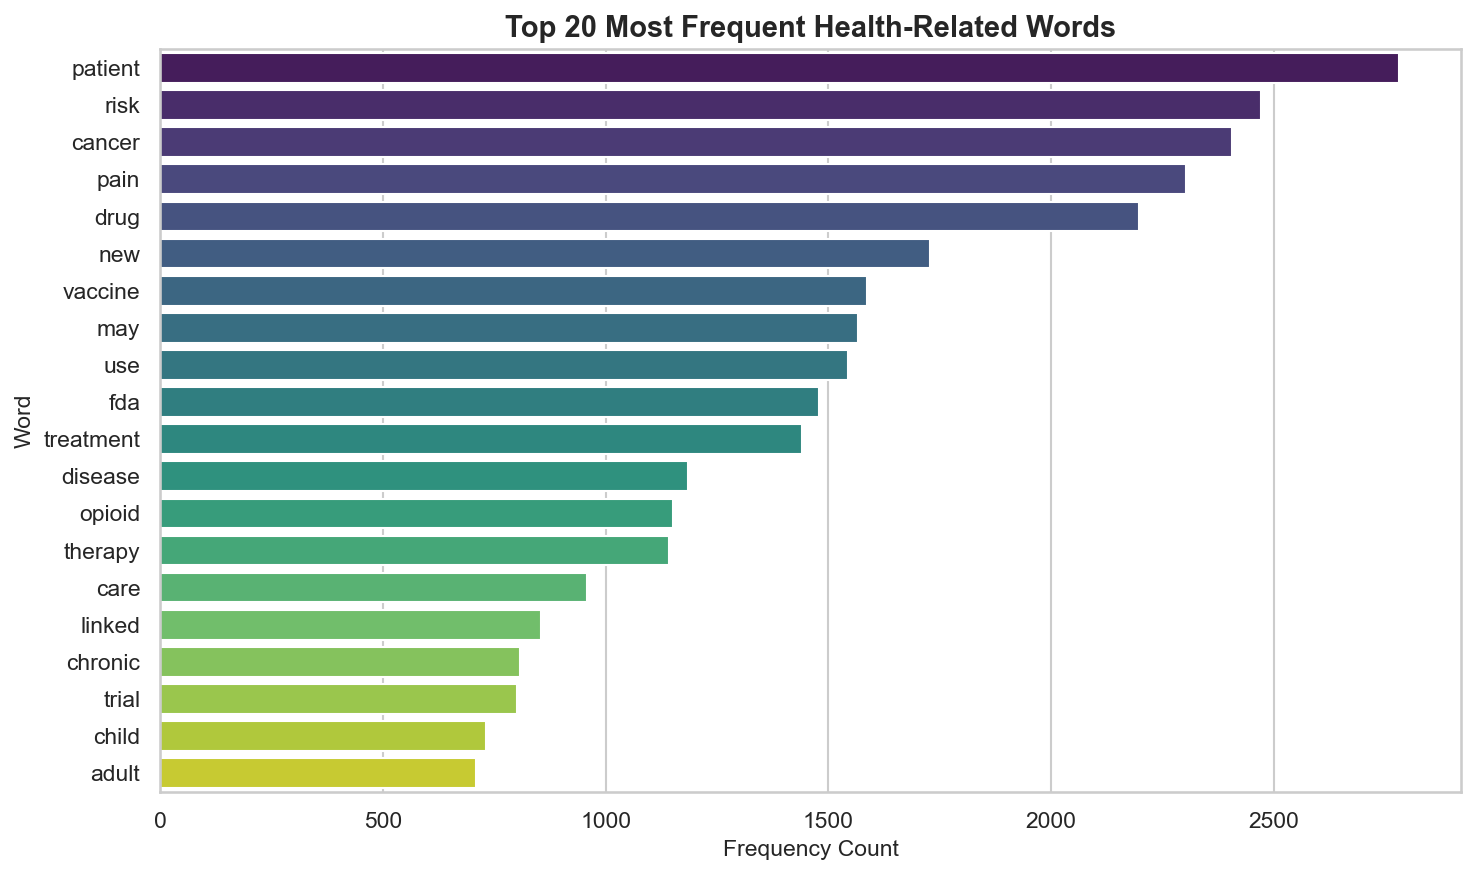

In [4]:
# [HINGLISH CODE EXPLANATION]:
# Saare cleaned words ki frequency calculate karke Top 20 words ka horizontal bar chart plot kar rahe hain.
all_words = ' '.join(df['Cleaned_Headlines']).split()
word_counts = Counter(all_words)

# Top 20 words DataFrame
top20_df = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])
print("Top 10 Most Common Health Terms:")
display(top20_df.head(10))

# Plot Top 20 frequent words
plt.figure(figsize=(10, 6))
sns.barplot(data=top20_df, y='Word', x='Frequency', palette='viridis')
plt.title('Top 20 Most Frequent Health-Related Words', fontsize=14, fontweight='bold')
plt.xlabel('Frequency Count', fontsize=11)
plt.ylabel('Word', fontsize=11)
plt.tight_layout()
plt.show()


<string>:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


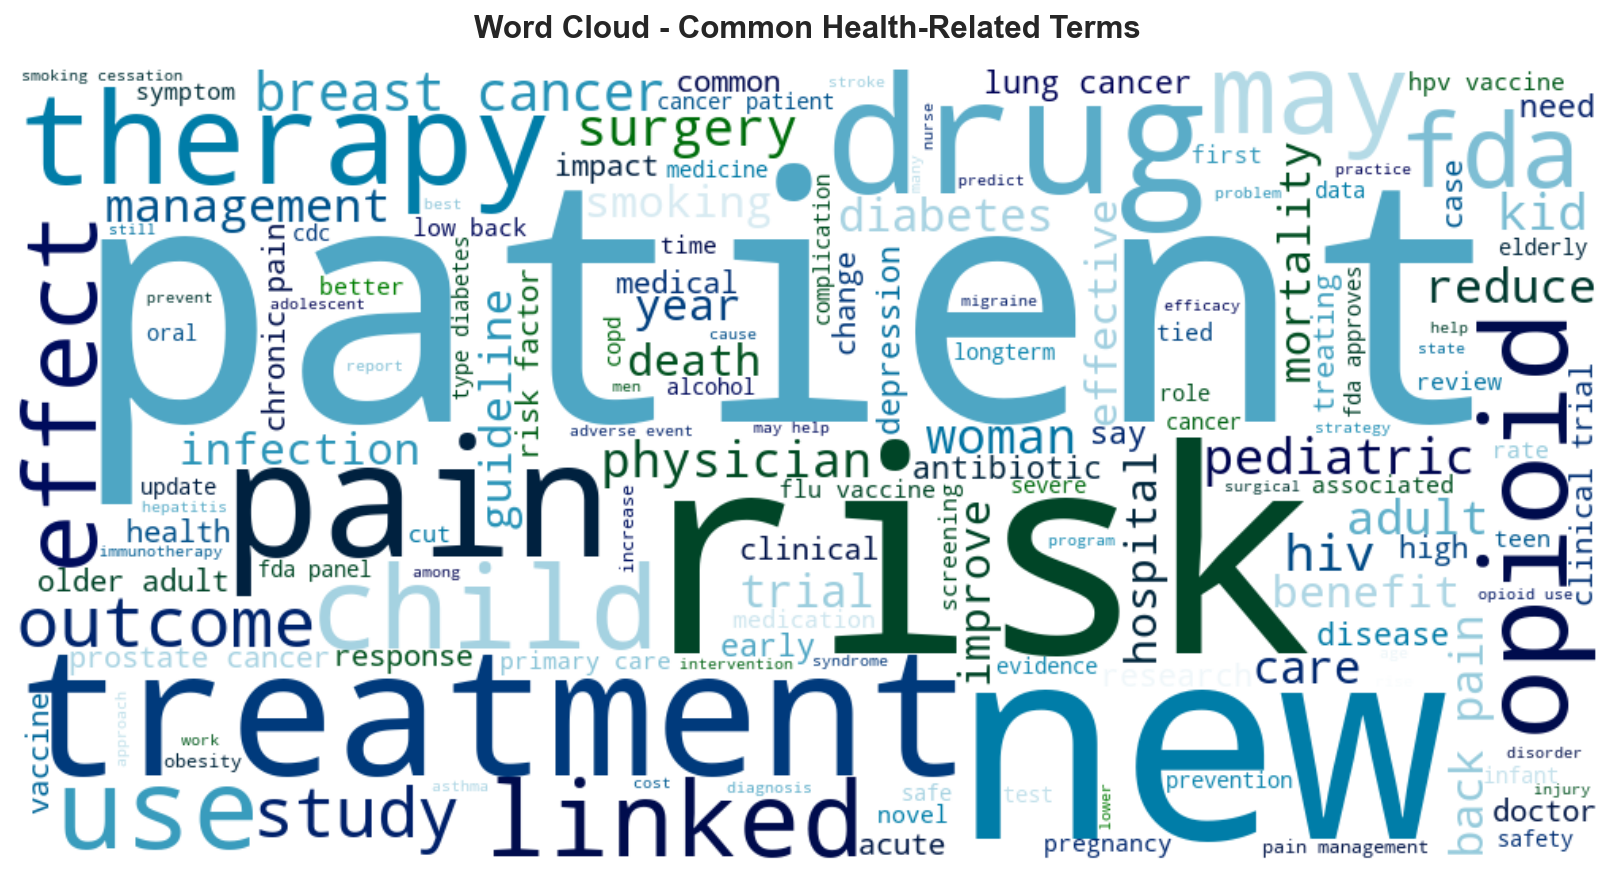

In [5]:
# [HINGLISH CODE EXPLANATION]:
# Cleaned corpus ka Word Cloud generate kar rahe hain taaki dominant health terms visually highlight ho sakein.
wc = WordCloud(width=1000, height=500, background_color='white', colormap='ocean', max_words=150).generate(' '.join(df['Cleaned_Headlines']))

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Common Health-Related Terms', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


---
## Task 3: Topic Modelling using LDA (Latent Dirichlet Allocation)
- Build Document-Term Matrix (Bag of Words) using CountVectorizer
- Fit Latent Dirichlet Allocation (LDA) to identify dominant health topics
- Display top 5 words per topic
- Visualize topics interactively using pyLDAvis


In [6]:
# [HINGLISH CODE EXPLANATION]:
# CountVectorizer se Document-Term Matrix banakar LDA topic model fit kar rahe hain.
cv = CountVectorizer(max_df=0.95, min_df=5, max_features=2000, stop_words='english')
dtm = cv.fit_transform(df['Cleaned_Headlines'])

# LDA Model fit karna (5 dominant topics)
lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_model.fit(dtm)

print(f"Document-Term Matrix Shape: {dtm.shape[0]} documents x {dtm.shape[1]} terms")
print("[SUCCESS] LDA Model training complete!")


Document-Term Matrix Shape: 39405 documents x 2000 terms
[SUCCESS] LDA Model training complete!


In [7]:
# [HINGLISH CODE EXPLANATION]:
# Har discovered topic ke Top 5 representative words extract aur display kar rahe hain.
feature_names = cv.get_feature_names_out()
topics_dict = {}

print("=== DISCOVERED HEALTH TOPICS (TOP 5 WORDS) ===\n")
for topic_idx, topic in enumerate(lda_model.components_):
    top_5_words = [feature_names[i] for i in topic.argsort()[:-6:-1]]
    topic_name = f"Topic {topic_idx + 1}"
    topics_dict[topic_name] = top_5_words
    print(f"{topic_name}: {', '.join(top_5_words)}")

# Summary Table
topic_df = pd.DataFrame(topics_dict, index=[f"Word {i+1}" for i in range(5)])
print("\nTopic-Word Table:")
display(topic_df)


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5
Word 1,cancer,pain,fda,patient,vaccine
Word 2,risk,chronic,drug,trial,new
Word 3,patient,care,disease,infection,effect
Word 4,therapy,health,opioid,outcome,medical
Word 5,diabetes,use,safety,hiv,use


=== DISCOVERED HEALTH TOPICS (TOP 5 WORDS) ===

Topic 1: cancer, risk, patient, therapy, diabetes
Topic 2: pain, chronic, care, health, use
Topic 3: fda, drug, disease, opioid, safety
Topic 4: patient, trial, infection, outcome, hiv
Topic 5: vaccine, new, effect, medical, use

Topic-Word Table:
         Topic 1  Topic 2  Topic 3    Topic 4  Topic 5
Word 1    cancer     pain      fda    patient  vaccine
Word 2      risk  chronic     drug      trial      new
Word 3   patient     care  disease  infection   effect
Word 4   therapy   health   opioid    outcome  medical
Word 5  diabetes      use   safety        hiv      use


In [8]:
# [HINGLISH CODE EXPLANATION]:
# pyLDAvis se inter-topic distance aur term relevance ka interactive visualization render kar rahe hain.
from IPython.display import HTML

try:
    import pyLDAvis.lda_model
    vis_data = pyLDAvis.lda_model.prepare(lda_model, dtm, cv, sort_topics=False)
except (ImportError, AttributeError):
    try:
        import pyLDAvis.sklearn
        vis_data = pyLDAvis.sklearn.prepare(lda_model, dtm, cv, sort_topics=False)
    except (ImportError, AttributeError):
        from pyLDAvis import prepare
        vis_data = prepare(
            topic_term_dists=lda_model.components_ / lda_model.components_.sum(axis=1, keepdims=True),
            doc_topic_dists=lda_model.transform(dtm),
            doc_lengths=dtm.sum(axis=1).A1.astype(int),
            vocab=feature_names,
            term_frequency=dtm.sum(axis=0).A1.astype(int),
            sort_topics=False
        )

html_vis = pyLDAvis.prepared_data_to_html(vis_data)
display(HTML(html_vis))


---
## Summary of Results:
1. **Task 1 (Preprocessing):** Health headlines were cleaned using lowercasing, punctuation stripping, NLTK tokenization, English stop-word removal, and WordNet lemmatization.
2. **Task 2 (Word Analysis & Visualization):** Frequency distribution identified primary health keywords (e.g., *drug*, *patient*, *treatment*, *clinical*, *trial*). Word Cloud and Seaborn barplot effectively visualized the top terms.
3. **Task 3 (LDA Topic Modeling):** LDA extracted 5 distinct thematic topics reflecting clinical trials, drug treatments, patient safety, disease research, and public healthcare. pyLDAvis allowed interactive exploration of intertopic distances and keyword relevance.
